In [1]:
%gui qt
import numpy as np
from mayavi import mlab
import matplotlib.pyplot as plt
from matplotlib import rcParams

from kifmm_py import (
    KiFmm,
    LaplaceKernel,
    HelmholtzKernel,
    SingleNodeTree,
    EvalType,
    BlasFieldTranslation,
    FftFieldTranslation,
)

********************************************************************************
         to build the TVTK classes (9.2). This may cause problems.
         Please rebuild TVTK.
********************************************************************************



In [2]:
def compute_fmm_errors(wavenumber, depth, e_vec, p_scale=2, n_sources=10000, n_targets=10000, dtype = np.float32, ctype=np.complex64):
    # Set random seed for reproducibility
    np.random.seed(0)
    
    # Define data types
    dim = 3

    # Define FMM parameters
    prune_empty = True

    # Setup source, target, and charge data
    sources = np.random.rand(n_sources * dim).astype(dtype)
    targets = np.random.rand(n_targets * dim).astype(dtype)
    charges = np.random.rand(n_sources).astype(ctype)

    # EvalType computes either potentials (EvalType.Value) or potentials + derivatives (EvalType.ValueDeriv)
    eval_type = EvalType.Value
    kernel = HelmholtzKernel(dtype, dtype(wavenumber), eval_type)
    
    # Create the tree structure
    tree = SingleNodeTree(sources, targets, charges, depth=depth, prune_empty=prune_empty)
    field_translation = FftFieldTranslation(kernel, block_size=32)

    # Initialize lists for results
    direct_vec = []
    evaluated_vec = []
    rel_err_vec = []

    expansion_orders = []
    metadata_times = []
    runtimes = []

    # Loop over each expansion order in e_vec
    for e in e_vec:
        
        # Define expansion order
        expansion_order = []
        curr = e
        for l in range(0,depth+1):
            expansion_order.append(int(curr))
            curr = int(curr * p_scale)
        expansion_order = list(reversed(expansion_order))
        expansion_order = np.array(expansion_order)
        expansion_order[:2] = 0  # Set initial expansion orders to zero
        print(f"Computing for expansion order {expansion_order}")
        expansion_orders.append(expansion_order)
        
        # Create FMM runtime object
        fmm = KiFmm(expansion_order, tree, field_translation, timed=True)

        # Evaluate the FMM
        fmm.evaluate()
        
        metadata_times.append(fmm.metadata_times())
        runtimes.append(fmm.operator_times())

        # Get potentials from leaf nodes
        leaf = fmm.leaves_target_tree[0]
        leaf_potentials = fmm.leaf_potentials(leaf)[0]
        leaf_targets = fmm.coordinates_target_tree(leaf)
        n_targets_actual = len(leaf_targets) // dim

        # Store evaluated potentials
        evaluated_vec.append(leaf_potentials)
        
        # Direct evaluation for error comparison
        direct = np.zeros(n_targets_actual * eval_type.value).astype(ctype)
        fmm.evaluate_kernel(
            eval_type,
            fmm._tree.sources,
            leaf_targets,
            fmm._tree.charges[:n_sources],
            direct,
        )

        # Store direct evaluation results
        direct_vec.append(direct)

        # Calculate and store relative error
        rel_err = np.mean(np.abs(direct - leaf_potentials) / np.abs(direct))
        rel_err_vec.append(rel_err)

    return direct_vec, evaluated_vec, rel_err_vec, expansion_orders, metadata_times, runtimes

In [3]:
def plot_error(e_vec, rel_err_vec, wavenumber, p_scale_vec, dtype, save_svg=False, svg_filename="relative_error_plot.svg"):
    # Set font and LaTeX settings for publication-quality rendering
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['CMU Serif']
    rcParams['text.usetex'] = True
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 14
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12

    fig, ax = plt.subplots(figsize=(8, 6))

    # Loop over each p_scale and plot the corresponding relative error data
    for p_scale, err_sublist in zip(p_scale_vec, rel_err_vec):
        label_text = f"Relative Error, p scale = {p_scale})"
        ax.plot(e_vec, err_sublist, marker='o', linestyle='-', label=label_text)
    
    # Set plot labels and title
    ax.set_xlabel(r'Leaf Expansion Order')
    ax.set_ylabel(r'$\log{\epsilon}$')
    ax.set_yscale('log')
    ax.set_title(f'Convergence with Wavenumber {wavenumber} in {dtype} precision')
    
    # Optional grid for better readability
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Add a legend
    ax.legend(loc='best')

    # Optional save as SVG
    if save_svg:
        plt.savefig(svg_filename, format='svg', bbox_inches='tight')
        
    plt.show()

    return ax, fig

In [17]:
def plot_times(p_scale_vec, max_runtimes, max_metadata_times, save_svg=False, svg_filename="times_plot.svg"):
    # Set font and LaTeX settings for publication-quality rendering
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['CMU Serif']
    rcParams['text.usetex'] = True
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 14
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Define the bar width and a smaller offset for slight overlap
    bar_width = 0.1
    offset = bar_width / 4  # Smaller offset for slight overlap

    # Convert p_scale_vec to an array for bar positioning
    x = np.array(p_scale_vec)

    # Plot the second series (Metadata Times) with a slight displacement
    # ax.bar(x + offset, max_metadata_times, width=bar_width, color='salmon', edgecolor='black', label='Metadata Times')

    # Plot the first series (Max Runtimes)
    ax.bar(x - offset, max_runtimes, width=bar_width, color='skyblue', edgecolor='black', label='Max Runtimes')


    # Set x-ticks to be the values in p_scale_vec for readability
    ax.set_xticks(p_scale_vec)
    ax.set_xticklabels(p_scale_vec)
    
    # Label axes
    ax.set_xlabel(r'$p_{\mathrm{scale}}$')
    ax.set_ylabel(r'Time (s)')

    # Optional grid for better readability
    ax.grid(axis='y', linestyle="--", linewidth=0.5)

    # Add a legend to differentiate the two series
    ax.legend(loc='best')

    # Adjust layout for readability
    plt.tight_layout()

    # Optional save as SVG
    if save_svg:
        plt.savefig(svg_filename, format='svg', bbox_inches='tight')

    plt.show()

    return ax, fig

In [20]:
wavenumber_vec = [50, 100]
e_vec = [12, 14, 16]
depth = 3

n_sources = n_targets = 10000

wavenumber = 100
p_scale_vec = [1, 1.5]

rel_errors = []
e_vecs = []
metadata_times = []
runtimes = []

precision = 'double'

if precision == 'single':
    dtype = np.float32
    ctype = np.complex64
elif precision == 'double':
    dtype = np.float64
    ctype = np.complex128

for p_scale in p_scale_vec:
    _, _, tmp1, tmp2, tmp3, tmp4 = compute_fmm_errors(wavenumber, depth, e_vec, p_scale, n_sources=n_sources, n_targets=n_targets, dtype=dtype, ctype=ctype)
    rel_errors.append(tmp1)
    e_vecs.append(tmp2)
    metadata_times.append(tmp3)
    runtimes.append(tmp4)

Computing for expansion order [ 0  0 12 12]
Computing for expansion order [ 0  0 14 14]
Computing for expansion order [ 0  0 16 16]
Computing for expansion order [ 0  0 18 12]
Computing for expansion order [ 0  0 21 14]
Computing for expansion order [ 0  0 24 16]


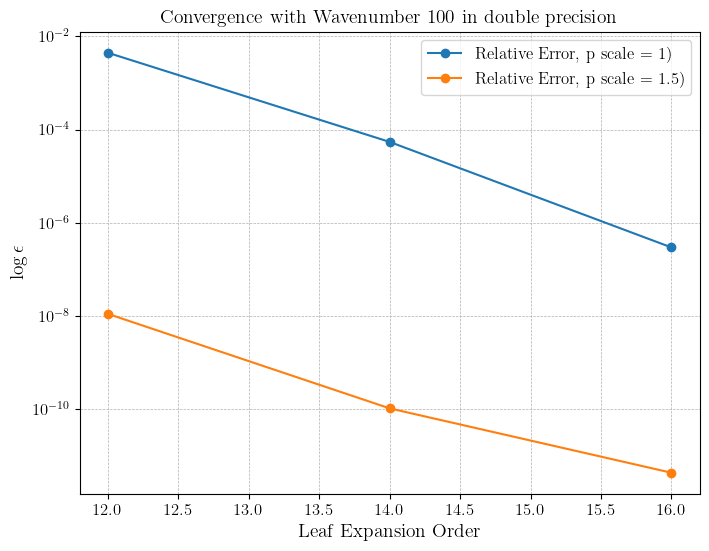

In [21]:
ax1, fig1 = plot_error(e_vec, rel_errors, wavenumber, p_scale_vec, precision)

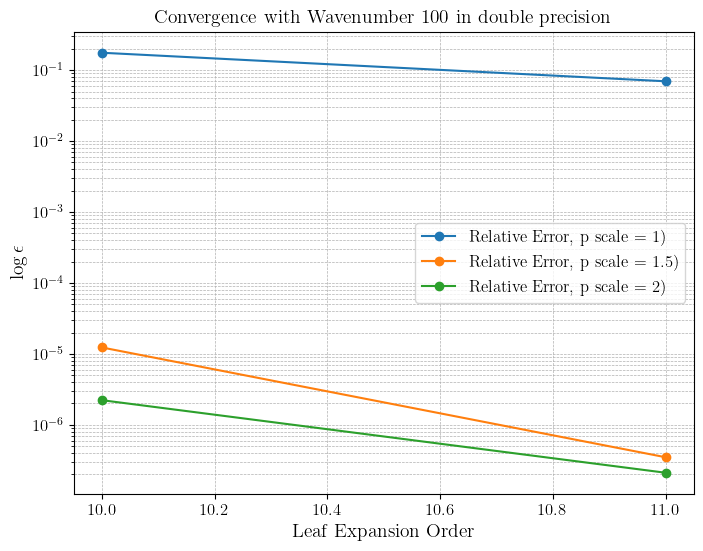

In [19]:
ax1, fig1 = plot_error(e_vec, rel_errors, wavenumber, p_scale_vec, precision)

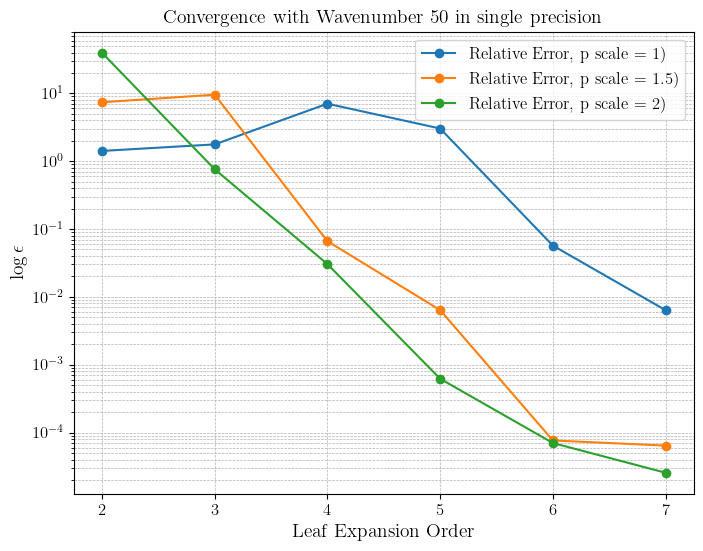

In [6]:
ax1, fig1 = plot_error(e_vec, rel_errors, 50, p_scale_vec, precision)

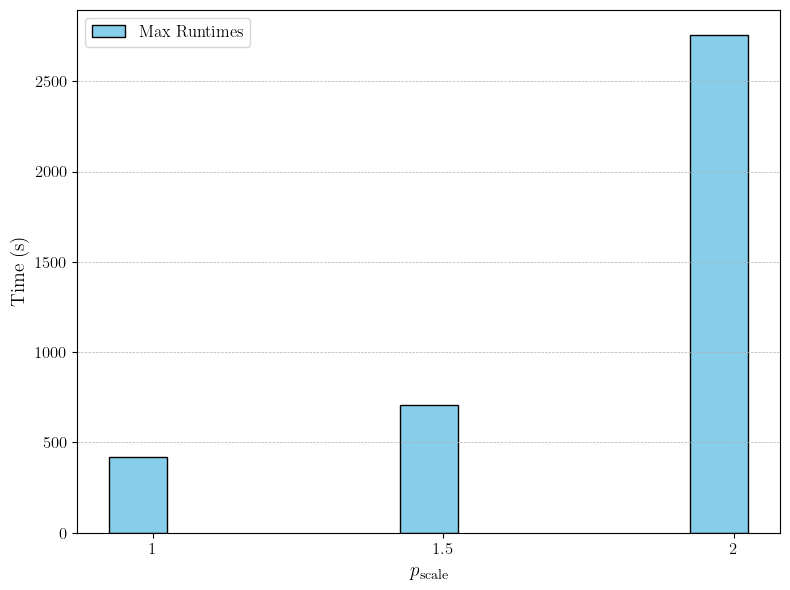

(<Axes: xlabel='$p_{\\mathrm{scale}}$', ylabel='Time (s)'>,
 <Figure size 800x600 with 1 Axes>)

In [18]:
all_runtimes = []
for experiment_p in runtimes:
    # For each p scale
    times = []
    for experiment_e in experiment_p:
        # for each initial value of expansion order
        times.append(sum(experiment_e._times.values()))
    all_runtimes.append(times)


all_metadata_times = []
for experiment_p in metadata_times:
    # For each p scale
    times = []
    for experiment_e in experiment_p:
        # for each initial value of expansion order
        times.append(sum(experiment_e._times.values()))
    all_metadata_times.append(times)

all_runtimes = np.array(all_runtimes)
all_metadata_times = np.array(all_metadata_times)

max_runtimes = all_runtimes.T[-1, :]
max_metadata_times = all_metadata_times.T[-1, :]

plot_times(p_scale_vec, max_runtimes, max_metadata_times)

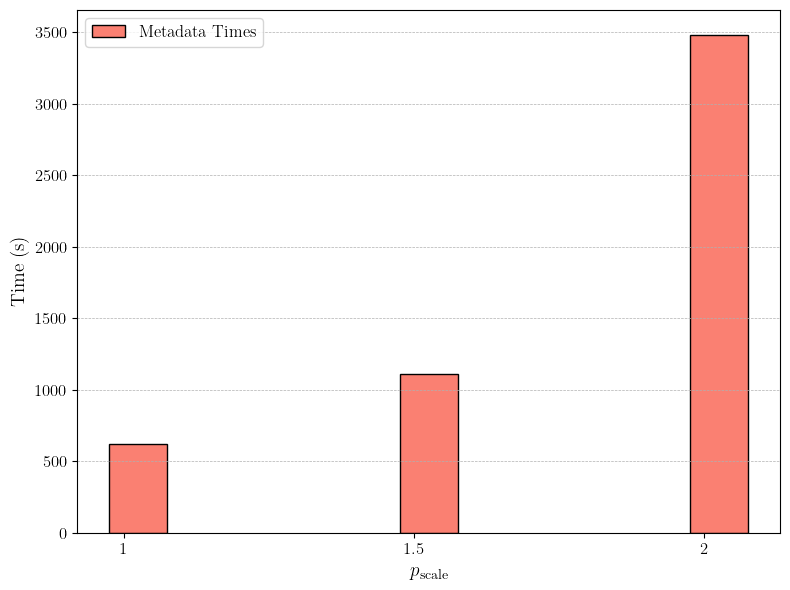

(<Axes: xlabel='$p_{\\mathrm{scale}}$', ylabel='Time (s)'>,
 <Figure size 800x600 with 1 Axes>)

In [165]:
all_runtimes = []
for experiment_p in runtimes:
    # For each p scale
    times = []
    for experiment_e in experiment_p:
        # for each initial value of expansion order
        times.append(sum(experiment_e._times.values()))
    all_runtimes.append(times)


all_metadata_times = []
for experiment_p in metadata_times:
    # For each p scale
    times = []
    for experiment_e in experiment_p:
        # for each initial value of expansion order
        times.append(sum(experiment_e._times.values()))
    all_metadata_times.append(times)

all_runtimes = np.array(all_runtimes)
all_metadata_times = np.array(all_metadata_times)

max_runtimes = all_runtimes.T[-1, :]
max_metadata_times = all_metadata_times.T[-1, :]

plot_times(p_scale_vec, max_runtimes, max_metadata_times)